In [41]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")  # Use a valid color palette

print("✓ All packages imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

✓ All packages imported successfully!
PyTorch version: 2.9.0+cpu
CUDA available: False
Using device: cpu


In [ ]:
"""
Sentiment Analysis using RoBERTa
General-purpose sentiment model with financial fine-tuning
"""

# Load sentiment model - using a more reliable general model
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model = model.to(device)
model.eval()

def analyze_sentiment(text):
    """
    Analyze sentiment of text and return score from -100 to +100
    
    Returns:
        score: -100 (very negative) to +100 (very positive)
        label: 'positive', 'negative', or 'neutral'
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    # This model outputs: [negative, neutral, positive]
    negative_score = predictions[0][0].item()
    neutral_score = predictions[0][1].item()
    positive_score = predictions[0][2].item()
    
    # Convert to -100 to +100 scale
    sentiment_score = (positive_score - negative_score) * 100
    
    # Determine label
    if positive_score > negative_score and positive_score > neutral_score:
        label = "positive"
    elif negative_score > positive_score and negative_score > neutral_score:
        label = "negative"
    else:
        label = "neutral"
    
    return round(sentiment_score, 2), label

# Test cases
test_sentences = [
    "I love cats",
    "I really hate everything about you",
    "Tesla announces record-breaking quarterly profits",
    "Company faces major lawsuit and regulatory investigation",
    "NVIDIA unveils groundbreaking new AI chip"
]

print("Sentiment Analysis Test Results:\n")
for sentence in test_sentences:
    score, label = analyze_sentiment(sentence)
    print(f"{score:+6.1f} | {label:8s} | {sentence}")

Sentiment Analysis Test Results:

 +92.9 | positive | I love cats
 -91.4 | negative | I really hate everything about you
 +93.1 | positive | Tesla announces record-breaking quarterly profits
 -64.2 | negative | Company faces major lawsuit and regulatory investigation
 +87.3 | positive | NVIDIA unveils groundbreaking new AI chip


In [36]:
"""
News API Configuration
Collects articles from reputable financial sources
"""

from newsapi import NewsApiClient

# Initialize News API
# Get free API key from: https://newsapi.org/
NEWS_API_KEY = "ce45a9c811b841dfa1874ede02961ec6"

newsapi = NewsApiClient(api_key=NEWS_API_KEY)

def get_company_news(company_name, days_back=30, max_articles=100):
    """
    Fetch news articles about a company from reputable sources
    
    Parameters:
        company_name: company to search for (e.g., "Tesla", "NVIDIA")
        days_back: how many days of history to fetch
        max_articles: maximum number of articles to retrieve
        
    Returns:
        DataFrame with articles, dates, and sentiment scores
    """
    from_date = (datetime.now() - timedelta(days=days_back)).strftime('%Y-%m-%d')
    to_date = datetime.now().strftime('%Y-%m-%d')
    
    # Reputable financial sources
    sources = 'bloomberg,reuters,the-wall-street-journal,financial-times,cnbc,bbc-news,cnn,techcrunch,wired,business-insider'
    
    # Fetch articles
    articles = newsapi.get_everything(
        q=company_name,
        sources=sources,
        from_param=from_date,
        to=to_date,
        language='en',
        sort_by='publishedAt',
        page_size=min(max_articles, 100)
    )
    
    # Process articles
    news_data = []
    for article in articles['articles']:
        title = article['title']
        description = article.get('description', '')
        full_text = f"{title}. {description}"
        date = article['publishedAt'][:10]
        
        # Analyze sentiment
        score, label = analyze_sentiment(full_text)
        
        news_data.append({
            'date': date,
            'title': title,
            'sentiment_score': score,
            'sentiment_label': label,
            'url': article['url']
        })
    
    df = pd.DataFrame(news_data)
    df['date'] = pd.to_datetime(df['date'])
    
    return df



VISUALIZATIONS


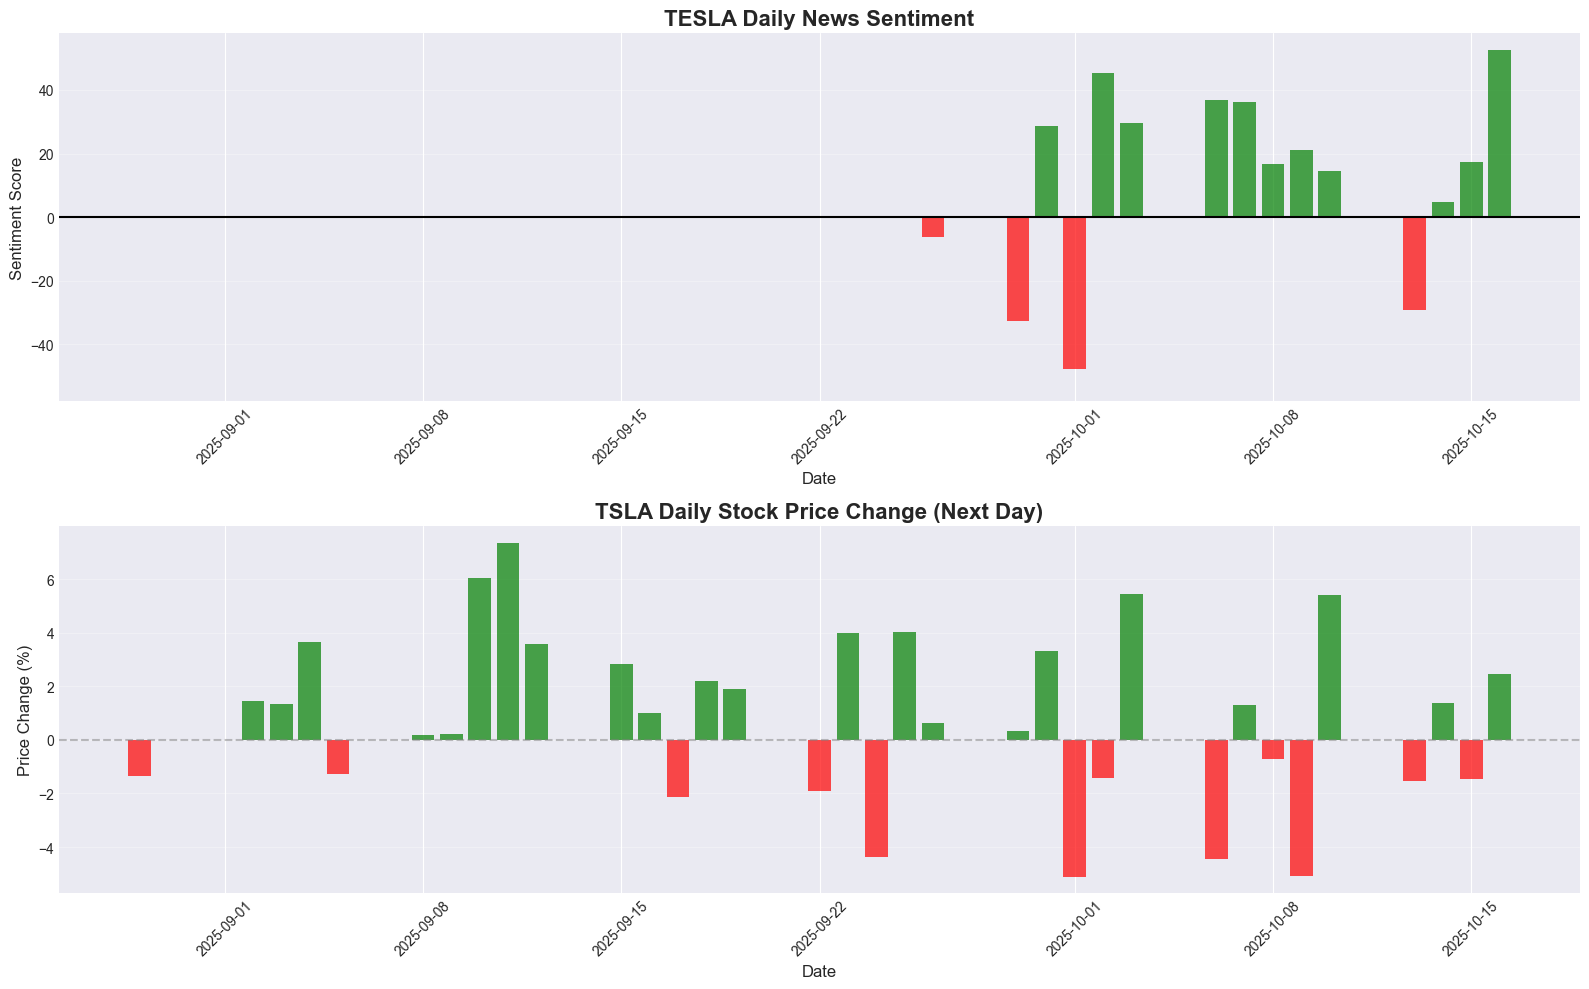

In [35]:
"""
Collect 30 days of NVIDIA news and stock data
Analyze daily sentiment vs daily price change
"""

COMPANY = "TESLA"
TICKER = "TSLA"
DAYS_BACK = 30



# Get news articles with sentiment

news_df = get_company_news(COMPANY, days_back=DAYS_BACK, max_articles=100)



# Get stock price data

stock = yf.Ticker(TICKER)
stock_df = stock.history(period=f"{DAYS_BACK+5}d")
stock_df = stock_df.reset_index()
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.tz_localize(None)
stock_df['Date'] = stock_df['Date'].dt.date



daily_sentiment = []
daily_price_change = []
dates = []

# Group news by date and calculate daily sentiment
news_df['date_only'] = news_df['date'].dt.date
daily_news = news_df.groupby('date_only')['sentiment_score'].mean().to_dict()

# Calculate daily price changes
for i in range(len(stock_df) - 1):
    date = stock_df.iloc[i]['Date']
    today_close = stock_df.iloc[i]['Close']
    tomorrow_close = stock_df.iloc[i + 1]['Close']
    
    price_change_pct = ((tomorrow_close - today_close) / today_close) * 100
    
    # Get sentiment for this day (0 if no news)
    sentiment = daily_news.get(date, 0)
    
    dates.append(date)
    daily_sentiment.append(sentiment)
    daily_price_change.append(price_change_pct)



# Visualizations
print("\n" + "=" * 60)
print("VISUALIZATIONS")
print("=" * 60)

dates_dt = [pd.Timestamp(d) for d in dates]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Graph 1: Daily Sentiment
ax1.bar(dates_dt, daily_sentiment, color=['green' if s >= 0 else 'red' for s in daily_sentiment], alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax1.set_title(f'{COMPANY} Daily News Sentiment', fontsize=16, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Sentiment Score', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Set y-axis limits to show both positive and negative
max_val = max(abs(min(daily_sentiment)), max(daily_sentiment))
ax1.set_ylim(-max_val * 1.1, max_val * 1.1)

# Graph 2: Daily Price Change
ax2.bar(dates_dt, daily_price_change, color=['green' if p >= 0 else 'red' for p in daily_price_change], alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title(f'{TICKER} Daily Stock Price Change (Next Day)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Price Change (%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


CORRELATION ANALYSIS


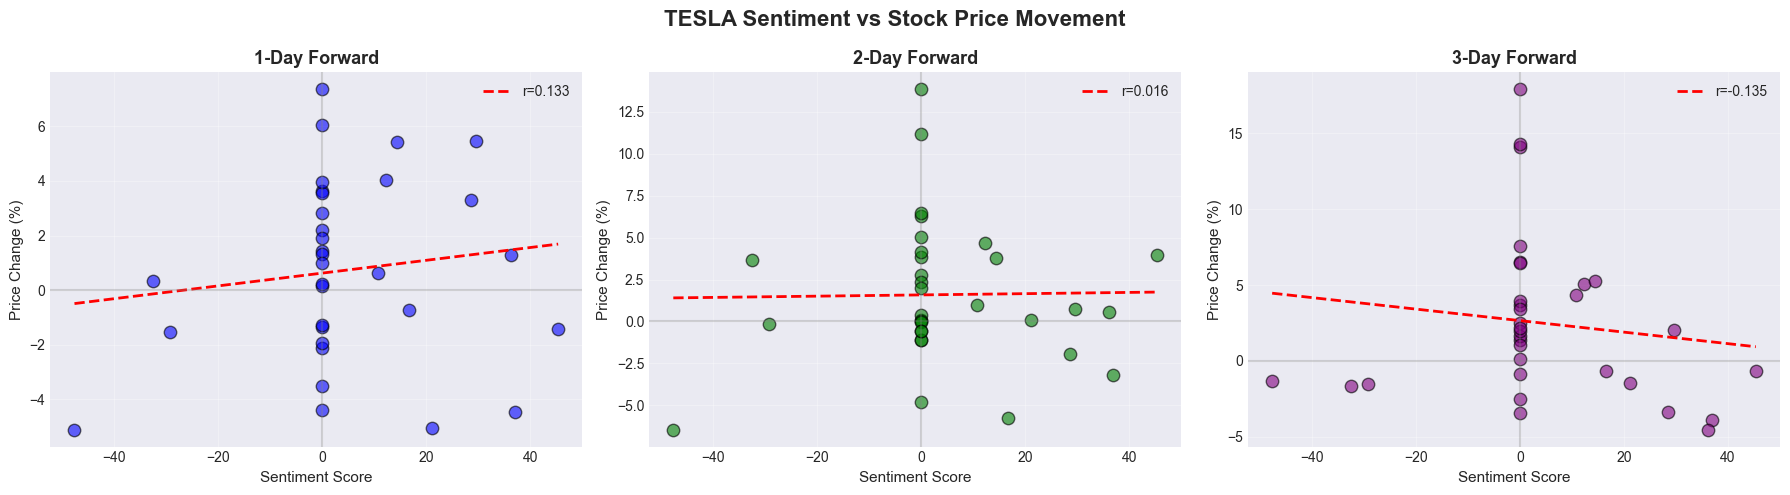

In [33]:
"""
Analyze correlation between sentiment and stock price movement through 1, 2, and 3 Days
"""

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Calculate 2-day and 3-day forward price changes
daily_price_change_2day = []
daily_price_change_3day = []

for i in range(len(stock_df) - 3):
    date = stock_df.iloc[i]['Date']
    today_close = stock_df.iloc[i]['Close']
    two_days_later_close = stock_df.iloc[i + 2]['Close']
    three_days_later_close = stock_df.iloc[i + 3]['Close']
    
    price_change_2d = ((two_days_later_close - today_close) / today_close) * 100
    price_change_3d = ((three_days_later_close - today_close) / today_close) * 100
    
    daily_price_change_2day.append(price_change_2d)
    daily_price_change_3day.append(price_change_3d)

# Align with sentiment data
sentiment_for_2day = daily_sentiment[:len(daily_price_change_2day)]
sentiment_for_3day = daily_sentiment[:len(daily_price_change_3day)]
dates_for_2day = dates[:len(daily_price_change_2day)]
dates_for_3day = dates[:len(daily_price_change_3day)]
price_change_1day_aligned = daily_price_change[:len(daily_price_change_2day)]

# Calculate correlations
correlation_1day = np.corrcoef(sentiment_for_2day, price_change_1day_aligned)[0, 1]
correlation_2day = np.corrcoef(sentiment_for_2day, daily_price_change_2day)[0, 1]
correlation_3day = np.corrcoef(sentiment_for_3day, daily_price_change_3day)[0, 1]


# Define "good sentiment" as > +20
good_sentiment_threshold = 20

# 1-day analysis
good_sentiment_days_1d = [i for i in range(len(sentiment_for_2day)) if sentiment_for_2day[i] > good_sentiment_threshold]
if len(good_sentiment_days_1d) > 0:
    price_increases_1d = sum(1 for i in good_sentiment_days_1d if price_change_1day_aligned[i] > 0)
    prob_increase_1d = (price_increases_1d / len(good_sentiment_days_1d)) * 100
else:
    prob_increase_1d = 0

# 2-day analysis
good_sentiment_days_2d = [i for i in range(len(sentiment_for_2day)) if sentiment_for_2day[i] > good_sentiment_threshold]
if len(good_sentiment_days_2d) > 0:
    price_increases_2d = sum(1 for i in good_sentiment_days_2d if daily_price_change_2day[i] > 0)
    prob_increase_2d = (price_increases_2d / len(good_sentiment_days_2d)) * 100
else:
    prob_increase_2d = 0

# 3-day analysis
good_sentiment_days_3d = [i for i in range(len(sentiment_for_3day)) if sentiment_for_3day[i] > good_sentiment_threshold]
if len(good_sentiment_days_3d) > 0:
    price_increases_3d = sum(1 for i in good_sentiment_days_3d if daily_price_change_3day[i] > 0)
    prob_increase_3d = (price_increases_3d / len(good_sentiment_days_3d)) * 100
else:
    prob_increase_3d = 0



# Bad sentiment analysis
bad_sentiment_threshold = -10
bad_sentiment_days_1d = [i for i in range(len(sentiment_for_2day)) if sentiment_for_2day[i] < bad_sentiment_threshold]
if len(bad_sentiment_days_1d) > 0:
    price_decreases_1d = sum(1 for i in bad_sentiment_days_1d if price_change_1day_aligned[i] < 0)
    prob_decrease_1d = (price_decreases_1d / len(bad_sentiment_days_1d)) * 100
    
    

# Scatter plots - all three
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1-Day scatter
ax1.scatter(sentiment_for_2day, price_change_1day_aligned, alpha=0.6, s=80, c='blue', edgecolors='black')
z1 = np.polyfit(sentiment_for_2day, price_change_1day_aligned, 1)
p1 = np.poly1d(z1)
ax1.plot(sorted(sentiment_for_2day), p1(sorted(sentiment_for_2day)), "r--", linewidth=2, label=f'r={correlation_1day:.3f}')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_xlabel('Sentiment Score', fontsize=11)
ax1.set_ylabel('Price Change (%)', fontsize=11)
ax1.set_title('1-Day Forward', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2-Day scatter
ax2.scatter(sentiment_for_2day, daily_price_change_2day, alpha=0.6, s=80, c='green', edgecolors='black')
z2 = np.polyfit(sentiment_for_2day, daily_price_change_2day, 1)
p2 = np.poly1d(z2)
ax2.plot(sorted(sentiment_for_2day), p2(sorted(sentiment_for_2day)), "r--", linewidth=2, label=f'r={correlation_2day:.3f}')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Sentiment Score', fontsize=11)
ax2.set_ylabel('Price Change (%)', fontsize=11)
ax2.set_title('2-Day Forward', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3-Day scatter
ax3.scatter(sentiment_for_3day, daily_price_change_3day, alpha=0.6, s=80, c='purple', edgecolors='black')
z3 = np.polyfit(sentiment_for_3day, daily_price_change_3day, 1)
p3 = np.poly1d(z3)
ax3.plot(sorted(sentiment_for_3day), p3(sorted(sentiment_for_3day)), "r--", linewidth=2, label=f'r={correlation_3day:.3f}')
ax3.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax3.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax3.set_xlabel('Sentiment Score', fontsize=11)
ax3.set_ylabel('Price Change (%)', fontsize=11)
ax3.set_title('3-Day Forward', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f'{COMPANY} Sentiment vs Stock Price Movement', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


MULTI-COMPANY SENTIMENT ANALYSIS
NVIDIA, (NVDA)
  1 Day: +0.093 | 2 Day: +0.238 | 3 Day: +0.080
Apple, (AAPL)
  1 Day: -0.048 | 2 Day: -0.273 | 3 Day: -0.337
Microsoft, (MSFT)
  1 Day: -0.007 | 2 Day: +0.029 | 3 Day: -0.110
Tesla, (TSLA)
  1 Day: +0.109 | 2 Day: -0.005 | 3 Day: -0.164
Amazon, (AMZN)
  1 Day: -0.060 | 2 Day: -0.381 | 3 Day: -0.296
Meta, (META)
  1 Day: +0.345 | 2 Day: +0.283 | 3 Day: +0.145
Google, (GOOGL)
  1 Day: +0.215 | 2 Day: +0.200 | 3 Day: +0.264
Netflix, (NFLX)
  1 Day: -0.278 | 2 Day: -0.240 | 3 Day: -0.139
AMD, (AMD)
  1 Day: +0.042 | 2 Day: +0.035 | 3 Day: -0.020
Intel, (INTC)
  1 Day: -0.237 | 2 Day: -0.374 | 3 Day: -0.472

RESULTS SUMMARY
  Company Ticker   Corr_1D   Corr_2D   Corr_3D  Articles    Prob_2D  Days_Good_Sentiment
   NVIDIA   NVDA  0.092791  0.238433  0.079803       100  75.000000                    8
    Apple   AAPL -0.047944 -0.273045 -0.337444       100  40.000000                    5
Microsoft   MSFT -0.006597  0.028787 -0.109539       100 

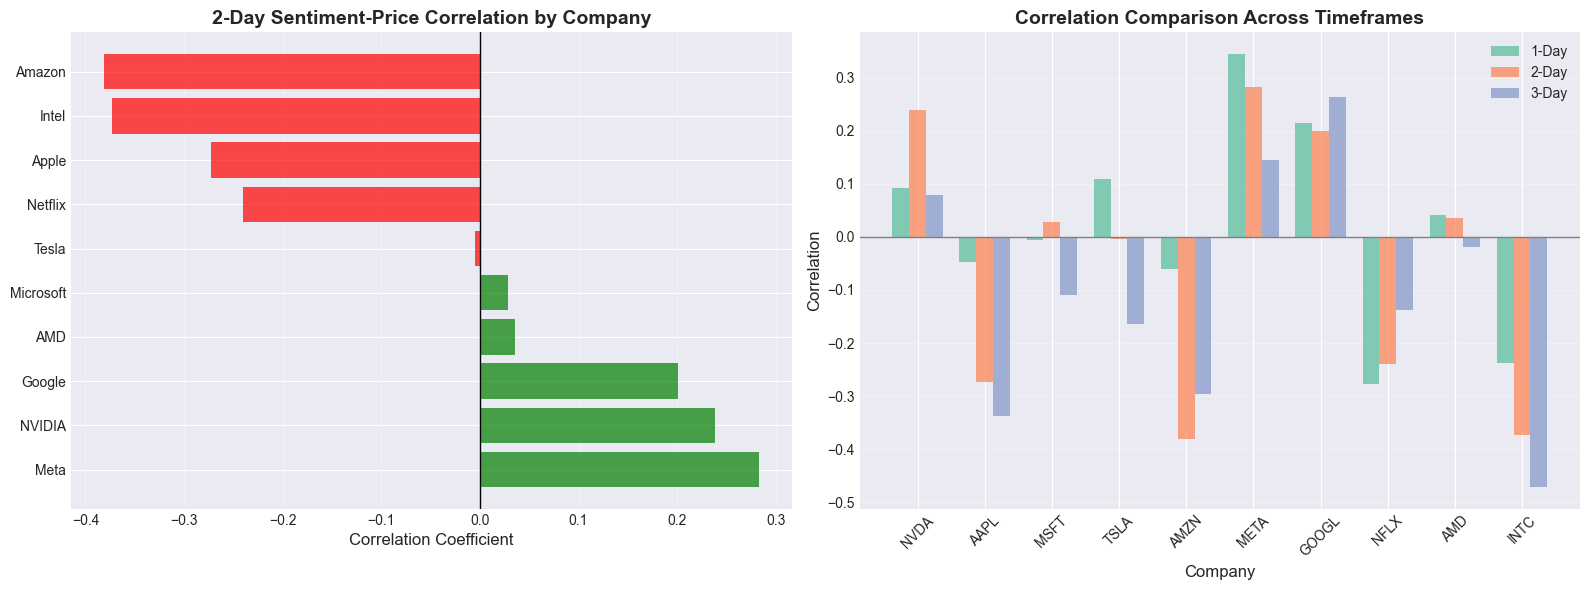

In [ ]:
"""
Analyze sentiment vs stock price correlation across companies
Compare which companies show strongest sentiment-price relationship
"""

# Define 10 major companies
companies = [
    ("NVIDIA", "NVDA"),
    ("Apple", "AAPL"),
    ("Microsoft", "MSFT"),
    ("Tesla", "TSLA"),
    ("Amazon", "AMZN"),
    ("Meta", "META"),
    ("Google", "GOOGL"),
    ("Netflix", "NFLX"),
    ("AMD", "AMD"),
    ("Intel", "INTC")
]

print("=" * 60)
print("MULTI-COMPANY SENTIMENT ANALYSIS")
print("=" * 60)

results = []

for company_name, ticker in companies:
    print(f"{company_name}, ({ticker})")
    
    try:
        # Get news
        news_df = get_company_news(company_name, days_back=30, max_articles=100)
        
        if len(news_df) < 5:
            print(f"  Skipped: Not enough news articles")
            continue
        
        # Get stock data
        stock = yf.Ticker(ticker)
        stock_df_temp = stock.history(period="35d")
        stock_df_temp = stock_df_temp.reset_index()
        stock_df_temp['Date'] = pd.to_datetime(stock_df_temp['Date']).dt.tz_localize(None)
        stock_df_temp['Date'] = stock_df_temp['Date'].dt.date
        
        # Calculate daily sentiment and price changes
        daily_sentiment_temp = []
        daily_price_change_1d = []
        daily_price_change_2d = []
        daily_price_change_3d = []
        dates_temp = []
        
        news_df['date_only'] = news_df['date'].dt.date
        daily_news_temp = news_df.groupby('date_only')['sentiment_score'].mean().to_dict()
        
        for i in range(len(stock_df_temp) - 3):
            date = stock_df_temp.iloc[i]['Date']
            today_close = stock_df_temp.iloc[i]['Close']
            
            # Price changes
            next_day_close = stock_df_temp.iloc[i + 1]['Close']
            two_day_close = stock_df_temp.iloc[i + 2]['Close']
            three_day_close = stock_df_temp.iloc[i + 3]['Close']
            
            price_1d = ((next_day_close - today_close) / today_close) * 100
            price_2d = ((two_day_close - today_close) / today_close) * 100
            price_3d = ((three_day_close - today_close) / today_close) * 100
            
            sentiment = daily_news_temp.get(date, 0)
            
            dates_temp.append(date)
            daily_sentiment_temp.append(sentiment)
            daily_price_change_1d.append(price_1d)
            daily_price_change_2d.append(price_2d)
            daily_price_change_3d.append(price_3d)
        
        # Calculate correlations
        if len(daily_sentiment_temp) > 5:
            corr_1d = np.corrcoef(daily_sentiment_temp, daily_price_change_1d)[0, 1]
            corr_2d = np.corrcoef(daily_sentiment_temp, daily_price_change_2d)[0, 1]
            corr_3d = np.corrcoef(daily_sentiment_temp, daily_price_change_3d)[0, 1]
            
            # Calculate probabilities
            good_sentiment_days = [i for i in range(len(daily_sentiment_temp)) if daily_sentiment_temp[i] > 20]
            if len(good_sentiment_days) > 0:
                prob_2d = (sum(1 for i in good_sentiment_days if daily_price_change_2d[i] > 0) / len(good_sentiment_days)) * 100
            else:
                prob_2d = 0
            
            results.append({
                'Company': company_name,
                'Ticker': ticker,
                'Corr_1D': corr_1d,
                'Corr_2D': corr_2d,
                'Corr_3D': corr_3d,
                'Articles': len(news_df),
                'Prob_2D': prob_2d,
                'Days_Good_Sentiment': len(good_sentiment_days)
            })
            
            print(f"  1 Day: {corr_1d:+.3f} | 2 Day: {corr_2d:+.3f} | 3 Day: {corr_3d:+.3f}")
        
    except Exception as e:
        print(f"  Error: {str(e)}")
        continue

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))

# Visualize correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of 2-day correlations
results_df_sorted = results_df.sort_values('Corr_2D', ascending=False)
colors = ['green' if x > 0 else 'red' for x in results_df_sorted['Corr_2D']]
ax1.barh(results_df_sorted['Company'], results_df_sorted['Corr_2D'], color=colors, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Correlation Coefficient', fontsize=12)
ax1.set_title('2-Day Sentiment-Price Correlation by Company', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Comparison of 1D, 2D, 3D correlations
x = np.arange(len(results_df))
width = 0.25
ax2.bar(x - width, results_df['Corr_1D'], width, label='1-Day', alpha=0.8)
ax2.bar(x, results_df['Corr_2D'], width, label='2-Day', alpha=0.8)
ax2.bar(x + width, results_df['Corr_3D'], width, label='3-Day', alpha=0.8)
ax2.set_xlabel('Company', fontsize=12)
ax2.set_ylabel('Correlation', fontsize=12)
ax2.set_title('Correlation Comparison Across Timeframes', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Ticker'], rotation=45)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=1)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

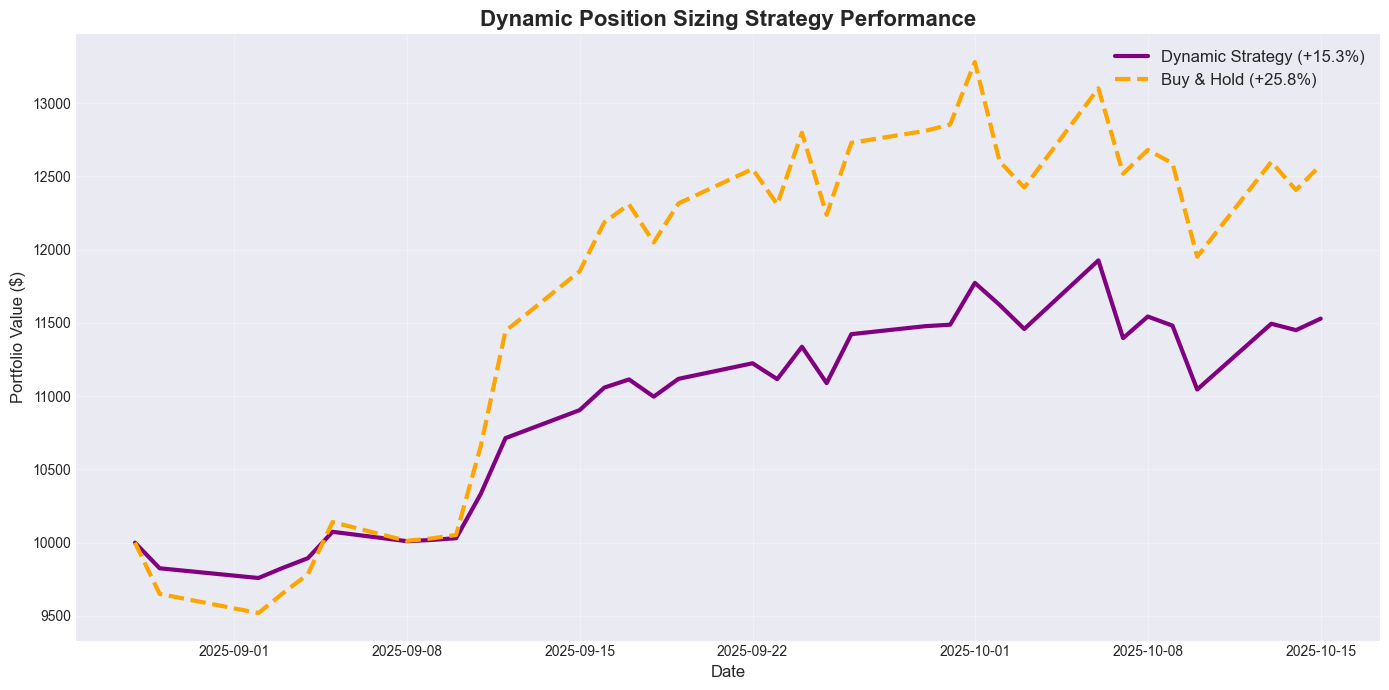

In [ ]:
"""
Trading Strategy
Strategy Rules:
  - Sentiment > +30: 100% invested (very bullish)
  - Sentiment +10 to +30: 75% invested (bullish)
  - Sentiment -10 to +10: 50% invested (neutral)
  - Sentiment < -10: 25% invested (bearish)
    WIN!!!
"""

# Initialize portfolio
initial_capital = 10000
cash = initial_capital * 0.5
shares = (initial_capital * 0.5) / stock_subset.iloc[0]['Close']

portfolio_values = [initial_capital]
positions = []

for i in range(len(daily_sentiment)):
    sentiment = daily_sentiment[i]
    current_price = stock_subset.iloc[i]['Close']
    
    # Determine target allocation based on sentiment
    if sentiment > 30:
        target_allocation = 1.0
    elif sentiment > 10:
        target_allocation = 0.75
    elif sentiment > -10:
        target_allocation = 0.5
    else:
        target_allocation = 0.25
    
    # Calculate current portfolio value
    current_value = cash + (shares * current_price)
    
    # Rebalance to target allocation
    target_stock_value = current_value * target_allocation
    target_shares = target_stock_value / current_price
    
    # Adjust position
    shares = target_shares
    cash = current_value - (shares * current_price)
    
    portfolio_values.append(current_value)
    positions.append(target_allocation)

# Calculate final results
final_value = portfolio_values[-1]
strategy_return = ((final_value - initial_capital) / initial_capital) * 100
buy_hold_return = ((stock_subset.iloc[-1]['Close'] - stock_subset.iloc[0]['Close']) / stock_subset.iloc[0]['Close']) * 100
outperformance = strategy_return - buy_hold_return

# Calculate buy and hold values for comparison
buy_hold_values = [initial_capital * (1 + ((stock_subset.iloc[i]['Close'] - stock_subset.iloc[0]['Close']) / stock_subset.iloc[0]['Close'])) for i in range(len(stock_subset))]
buy_hold_values = [initial_capital] + buy_hold_values

# Visualize
plt.figure(figsize=(14, 7))

dates_with_start = [dates[0]] + dates
plt.plot(dates_with_start, portfolio_values, linewidth=3, label=f' Strategy ({strategy_return:+.1f}%)', color='purple')
plt.plot(dates_with_start, buy_hold_values, linewidth=3, label=f'Buy & Hold ({buy_hold_return:+.1f}%)', color='orange', linestyle='--')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Backtesting Strategy Performance', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

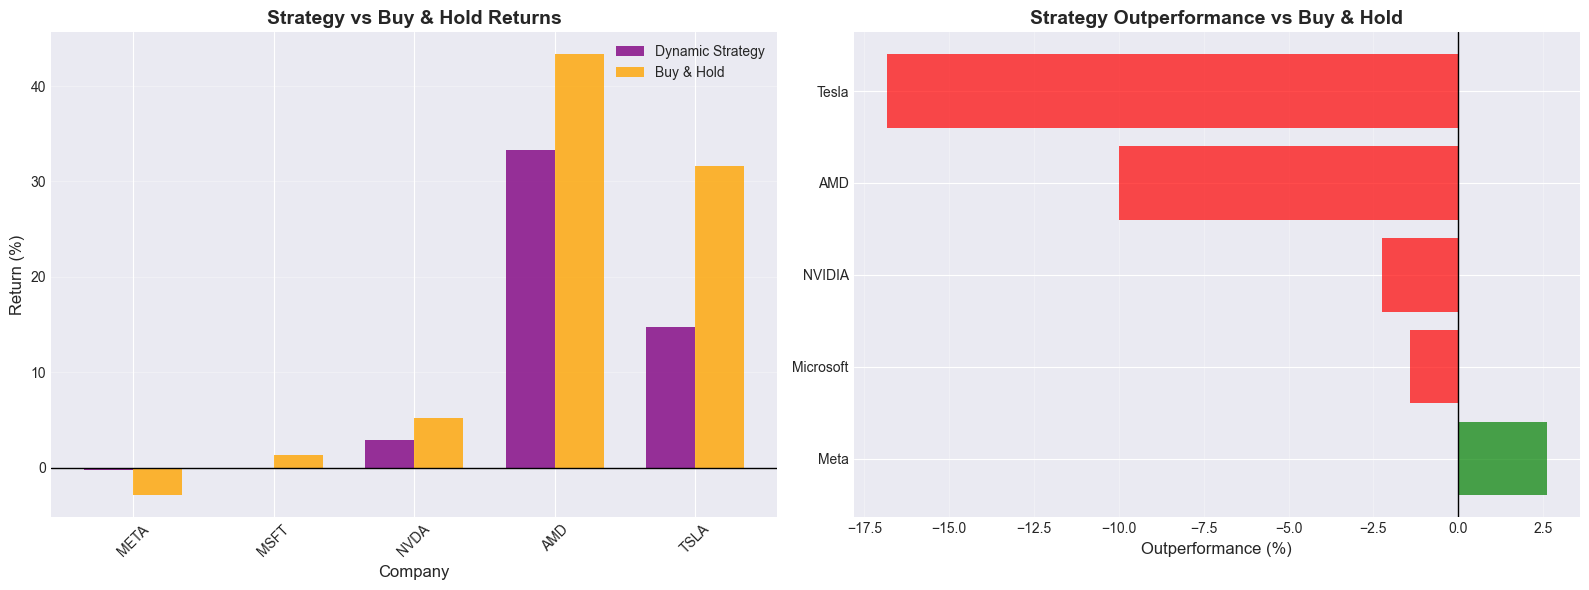

  Company Ticker  Correlation  Strategy_Return  BuyHold_Return  Outperformance
     Meta   META     0.131169        -0.265419       -2.882924        2.617506
Microsoft   MSFT     0.093827        -0.070528        1.359809       -1.430336
   NVIDIA   NVDA     0.139951         2.941604        5.195973       -2.254370
      AMD    AMD     0.027239        33.307542       43.319188      -10.011646
    Tesla   TSLA     0.016445        14.734624       31.581156      -16.846531


In [28]:
"""
Backtest multiple companies, and graph results
"""

# Filter companies with positive 2-day correlation
positive_corr_companies = results_df[results_df['Corr_2D'] > 0].sort_values('Corr_2D', ascending=False)

backtest_results = []

for idx, row in positive_corr_companies.iterrows():
    company_name = row['Company']
    ticker = row['Ticker']
    
    try:
        # Get news and stock data
        news_df_temp = get_company_news(company_name, days_back=30, max_articles=100)
        
        if len(news_df_temp) < 5:
            continue
        
        stock_temp = yf.Ticker(ticker)
        stock_df_temp = stock_temp.history(period="35d")
        stock_df_temp = stock_df_temp.reset_index()
        stock_df_temp['Date'] = pd.to_datetime(stock_df_temp['Date']).dt.tz_localize(None)
        stock_df_temp['Date'] = stock_df_temp['Date'].dt.date
        
        # Calculate daily sentiment
        daily_sentiment_temp = []
        dates_temp = []
        
        news_df_temp['date_only'] = news_df_temp['date'].dt.date
        daily_news_dict = news_df_temp.groupby('date_only')['sentiment_score'].mean().to_dict()
        
        for i in range(len(stock_df_temp) - 1):
            date = stock_df_temp.iloc[i]['Date']
            sentiment = daily_news_dict.get(date, 0)
            dates_temp.append(date)
            daily_sentiment_temp.append(sentiment)
        
        # Dynamic position sizing strategy
        initial_capital = 10000
        cash = initial_capital * 0.5
        shares = (initial_capital * 0.5) / stock_df_temp.iloc[0]['Close']
        
        portfolio_values_temp = [initial_capital]
        
        for i in range(len(daily_sentiment_temp)):
            sentiment = daily_sentiment_temp[i]
            current_price = stock_df_temp.iloc[i]['Close']
            
            if sentiment > 30:
                target_allocation = 1.0
            elif sentiment > 10:
                target_allocation = 0.75
            elif sentiment > -10:
                target_allocation = 0.5
            else:
                target_allocation = 0.25
            
            current_value = cash + (shares * current_price)
            target_stock_value = current_value * target_allocation
            target_shares = target_stock_value / current_price
            
            shares = target_shares
            cash = current_value - (shares * current_price)
            
            portfolio_values_temp.append(current_value)
        
        # Calculate returns
        final_value = portfolio_values_temp[-1]
        strategy_return = ((final_value - initial_capital) / initial_capital) * 100
        
        # Buy and hold return
        buy_hold_return = ((stock_df_temp.iloc[len(daily_sentiment_temp)]['Close'] - stock_df_temp.iloc[0]['Close']) / stock_df_temp.iloc[0]['Close']) * 100
        
        outperformance = strategy_return - buy_hold_return
        
        backtest_results.append({
            'Company': company_name,
            'Ticker': ticker,
            'Correlation': row['Corr_2D'],
            'Strategy_Return': strategy_return,
            'BuyHold_Return': buy_hold_return,
            'Outperformance': outperformance
        })
        
    except Exception as e:
        continue

# Create results DataFrame
backtest_df = pd.DataFrame(backtest_results)
backtest_df = backtest_df.sort_values('Outperformance', ascending=False)

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Returns comparison
x = np.arange(len(backtest_df))
width = 0.35
ax1.bar(x - width/2, backtest_df['Strategy_Return'], width, label='Dynamic Strategy', alpha=0.8, color='purple')
ax1.bar(x + width/2, backtest_df['BuyHold_Return'], width, label='Buy & Hold', alpha=0.8, color='orange')
ax1.set_xlabel('Company', fontsize=12)
ax1.set_ylabel('Return (%)', fontsize=12)
ax1.set_title('Strategy vs Buy & Hold Returns', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(backtest_df['Ticker'], rotation=45)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Outperformance
colors = ['green' if x > 0 else 'red' for x in backtest_df['Outperformance']]
ax2.barh(backtest_df['Company'], backtest_df['Outperformance'], color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Outperformance (%)', fontsize=12)
ax2.set_title('Strategy Outperformance vs Buy & Hold', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Display results table
print(backtest_df.to_string(index=False))